# HOLa-style predicate description low-rank decomposition

This notebook now follows the original HOLa implementation more closely.

Given CLIP/VLM text features `F ∈ R^{N×d}`, we learn:

- `hoicls_w = W ∈ R^{N×m}`: one weight vector per predicate / HOI class
- `basis_feat ∈ R^{m×d}`: shared low-rank basis features

and reconstruct text features with:

$$F \approx W \cdot \text{basis\_feat}$$

matching the original code path:

- reconstruction: `MSELoss(reduction="sum")(W @ basis_feat, F)`
- sparsity: `abs(W).sum(-1).mean(0)`
- disentangle basis: normalize each basis row, compute row-wise correlations, zero the diagonal, then penalize the squared correlation structure

If a predicate has no LLM description yet, it falls back to `a photo of {predicate}` and records that in metadata.


## 1. Configuration

Edit this cell before running. For a quick smoke test without the VG dict, set `PREDICATE_JSON = None` and use `PREDICATE_LIST`.

In [93]:
import os

REPO_ROOT = "/Users/shangfei/Developer/SDSGG"

# Use either PREDICATE_JSON or PREDICATE_LIST.
PREDICATE_JSON = "/workspace/ccloud/sf/SDSGG/datasets/vg/VG-SGG-dicts-with-attri.json"
PREDICATE_LIST = None  # Example: ["on", "under", "riding", "holding"]

# Optional LLM descriptions. Supported formats:
# JSON: {"on": "Objects are in contact...", "riding": "..."}
# CSV: columns must be predicate,description
DESCRIPTIONS = "/workspace/ccloud/sf/SDSGG/datasets/vg/descriptions.json"

CLIP_MODEL = "ViT-B/32"  # Or a local checkpoint path, e.g. "/path/to/ViT-B-32.pt"
DEVICE = "cuda"  # Change to "cpu" if needed.
RANK = 24  # Effective rank is capped to min(num_predicates, clip_dim).
BATCH_SIZE = 64
NORMALIZE_FEATURES = True
KEEP_BACKGROUND = False
PROMPT_TEMPLATE = "a photo of {predicate}"

# Match the original HOLa implementation more closely.
BASIS_INIT = "random"  # "random" or "pca"
RECON_RATIO_PCA = RANK  # If <= 1, PCA keeps that explained-variance ratio; else interpreted as rank.
FACTORIZATION_STEPS = 3000
FACTORIZATION_LR = 1e-2
BETA_RECON = 0.1
BETA_SPARSE = 0.1
BETA_ORTHO = 0.001
PRINT_EVERY = 250
SEED = 42

OUTPUT = os.path.join(REPO_ROOT, "outputs/hola_predicate_factors.pt")

# Optional VG triplet-statistics inputs for train/test analysis.

# If your environment is missing CLIP tokenizer dependencies, run this once:
# %pip install ftfy regex tqdm scikit-learn


## 2. Imports and helper functions

In [94]:
import csv
import json
import sys
from typing import Dict, List, Optional, Sequence, Tuple

import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.decomposition import PCA

LOCAL_CLIP_PARENT = os.path.join(
    REPO_ROOT, "maskrcnn_benchmark", "modeling", "roi_heads", "relation_head"
)
if LOCAL_CLIP_PARENT not in sys.path:
    sys.path.insert(0, LOCAL_CLIP_PARENT)

print("Repo root:", REPO_ROOT)
print("Local CLIP parent:", LOCAL_CLIP_PARENT)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repo root: /Users/shangfei/Developer/SDSGG
Local CLIP parent: /Users/shangfei/Developer/SDSGG/maskrcnn_benchmark/modeling/roi_heads/relation_head
Torch: 1.10.1+cu113
CUDA available: True


In [95]:
def normalize_key(text: str) -> str:
    return " ".join(str(text).strip().lower().split())


def load_predicates_from_json(path: str) -> List[Tuple[int, str]]:
    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if "idx_to_predicate" in payload:
        idx_to_predicate = payload["idx_to_predicate"]
        if isinstance(idx_to_predicate, dict):
            return sorted(
                ((int(index), name) for index, name in idx_to_predicate.items()),
                key=lambda item: item[0],
            )
        return [(index, name) for index, name in enumerate(idx_to_predicate)]

    if "predicate_to_idx" in payload:
        predicate_to_idx = payload["predicate_to_idx"]
        return sorted(
            ((int(index), name) for name, index in predicate_to_idx.items()),
            key=lambda item: item[0],
        )

    raise ValueError(
        f"No predicate mapping found in {path}. Expected idx_to_predicate or predicate_to_idx."
    )


def load_predicates_from_list(predicate_list: Sequence[str]) -> List[Tuple[int, str]]:
    predicates = [item.strip() for item in predicate_list if item and item.strip()]
    if not predicates:
        raise ValueError("PREDICATE_LIST is empty after parsing.")
    return list(enumerate(predicates))


def filter_background(predicates: Sequence[Tuple[int, str]], keep_background: bool) -> List[Tuple[int, str]]:
    if keep_background:
        return list(predicates)
    return [
        (index, name)
        for index, name in predicates
        if normalize_key(name) != "__background__"
    ]

In [96]:
def load_description_map(path: str) -> Dict[str, str]:
    ext = os.path.splitext(path)[1].lower()

    if ext == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        if not isinstance(payload, dict):
            raise ValueError("Description JSON must map predicate -> description.")
        return {normalize_key(key): str(value).strip() for key, value in payload.items()}

    if ext == ".csv":
        description_map = {}
        with open(path, "r", encoding="utf-8", newline="") as handle:
            reader = csv.DictReader(handle)
            required_fields = {"predicate", "description"}
            if not reader.fieldnames or not required_fields.issubset(reader.fieldnames):
                raise ValueError("Description CSV must contain predicate and description columns.")
            for row in reader:
                predicate = normalize_key(row["predicate"])
                description = row["description"].strip()
                if predicate:
                    description_map[predicate] = description
        return description_map

    raise ValueError(f"Unsupported description format: {path}. Use JSON or CSV.")


def resolve_descriptions(
    predicates: Sequence[Tuple[int, str]],
    description_map: Optional[Dict[str, str]],
    prompt_template: str,
) -> Tuple[List[str], List[bool]]:
    descriptions = []
    fallback_mask = []

    for _, predicate_name in predicates:
        description = ""
        if description_map is not None:
            description = description_map.get(normalize_key(predicate_name), "").strip()

        used_fallback = not description
        if used_fallback:
            description = prompt_template.format(predicate=predicate_name)

        descriptions.append(description)
        fallback_mask.append(used_fallback)

    return descriptions, fallback_mask

In [97]:
def encode_text_features(
    texts: Sequence[str],
    clip_model_name: str,
    device: str,
    batch_size: int,
) -> torch.Tensor:
    try:
        from CLIP import clip
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError(
            "Failed to import local CLIP dependencies. "
            "Install the missing package in this notebook kernel, e.g. `%pip install ftfy regex tqdm`. "
            f"Missing package: {error.name}"
        ) from error

    try:
        model, _ = clip.load(clip_model_name, device=device)
    except RuntimeError as error:
        raise RuntimeError(
            "Failed to load CLIP model. If weights are not cached locally, pass a local checkpoint "
            "path in CLIP_MODEL or prepare ~/.cache/clip first. "
            f"Original error: {error}"
        ) from error

    model.eval()
    features = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch_texts = list(texts[start:start + batch_size])
            tokens = clip.tokenize(batch_texts).to(device)
            batch_features = model.encode_text(tokens).float().cpu()
            features.append(batch_features)

    return torch.cat(features, dim=0)


def effective_rank(requested_rank: int, features: torch.Tensor) -> int:
    if requested_rank < 1:
        raise ValueError("RANK must be positive.")
    return min(requested_rank, features.shape[0], features.shape[1])


def init_hola_factors(
    features: torch.Tensor,
    requested_rank: int,
    init_method: str,
    seed: int,
    recon_ratio_pca,
) -> Tuple[torch.Tensor, torch.Tensor, int]:
    target = features.float().cpu()
    rank = effective_rank(requested_rank, target)
    num_classes, feature_dim = target.shape

    if init_method == "pca":
        n_components = recon_ratio_pca if recon_ratio_pca <= 1 else rank
        pca = PCA(n_components=n_components)
        pca.fit(target.t().numpy())
        basis_feat = torch.tensor(pca.transform(target.t().numpy()).T, dtype=target.dtype)
        basis_feat = basis_feat / basis_feat.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        hoicls_w = torch.tensor(pca.components_.T, dtype=target.dtype)
        rank = basis_feat.shape[0]
        return hoicls_w, basis_feat, rank

    if init_method == "random":
        generator = torch.Generator(device="cpu")
        generator.manual_seed(seed)
        basis_feat = torch.randn(rank, feature_dim, generator=generator, dtype=target.dtype)
        basis_feat = basis_feat / basis_feat.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        hoicls_w = target @ torch.pinverse(basis_feat)
        return hoicls_w, basis_feat, rank

    raise ValueError(f"Unsupported BASIS_INIT={init_method!r}. Use 'random' or 'pca'.")


def hola_disentangle_basis_loss(basis_feat: torch.Tensor) -> torch.Tensor:
    basis_feat = basis_feat / basis_feat.norm(dim=-1, keepdim=True).clamp_min(1e-12)
    corr = basis_feat @ basis_feat.t()
    corr = corr * (torch.ones_like(corr) - torch.eye(len(corr), device=corr.device, dtype=corr.dtype))
    corr = corr @ corr.t()
    return torch.abs(corr).sum()


def compute_low_rank_factors_learnable(
    features: torch.Tensor,
    requested_rank: int,
    steps: int,
    lr: float,
    beta_recon: float,
    beta_sparse: float,
    beta_ortho: float,
    seed: int,
    print_every: int,
    init_method: str,
    recon_ratio_pca,
):
    """Optimize HOLa-style factors with the same tensor layout and losses as the original implementation."""
    if steps < 1:
        raise ValueError("FACTORIZATION_STEPS must be positive.")

    target = features.float().cpu()
    init_W, init_basis_feat, rank = init_hola_factors(
        features=target,
        requested_rank=requested_rank,
        init_method=init_method,
        seed=seed,
        recon_ratio_pca=recon_ratio_pca,
    )

    hoicls_w = torch.nn.Parameter(init_W.clone())
    basis_feat = torch.nn.Parameter(init_basis_feat.clone())
    optimizer = torch.optim.Adam([hoicls_w, basis_feat], lr=lr)
    recon_loss_fn = torch.nn.MSELoss(reduction="sum")
    history = []

    for step in range(1, steps + 1):
        reconstructed = hoicls_w @ basis_feat
        recon_loss = recon_loss_fn(reconstructed, target)
        sparse_loss = torch.abs(hoicls_w).sum(-1).mean(0)
        ortho_loss = hola_disentangle_basis_loss(basis_feat)
        total_loss = beta_recon * recon_loss + beta_sparse * sparse_loss + beta_ortho * ortho_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        if print_every and (step == 1 or step % print_every == 0 or step == steps):
            record = {
                "step": step,
                "total_loss": float(total_loss.detach().cpu()),
                "recon_loss": float(recon_loss.detach().cpu()),
                "sparse_loss": float(sparse_loss.detach().cpu()),
                "ortho_loss": float(ortho_loss.detach().cpu()),
            }
            history.append(record)
            print(record)

    with torch.no_grad():
        final_W = hoicls_w.detach().cpu()
        final_basis_feat = basis_feat.detach().cpu()
        reconstructed = final_W @ final_basis_feat
        reconstruction_error = torch.norm(target - reconstructed, p="fro")
        final_recon_loss = recon_loss_fn(reconstructed, target)
        final_sparse_loss = torch.abs(final_W).sum(-1).mean(0)
        final_ortho_loss = hola_disentangle_basis_loss(final_basis_feat)
        final_total_loss = beta_recon * final_recon_loss + beta_sparse * final_sparse_loss + beta_ortho * final_ortho_loss

    return {
        "W": final_W,
        "basis_feat": final_basis_feat,
        "B": final_basis_feat.t(),  # Column-major alias if downstream code expects d x m.
        "M": final_basis_feat,      # Original HOLa-style reconstruction uses W @ basis_feat.
        "reconstructed": reconstructed,
        "rank": rank,
        "reconstruction_error": reconstruction_error,
        "final_total_loss": final_total_loss,
        "final_recon_loss": final_recon_loss,
        "final_sparse_loss": final_sparse_loss,
        "final_ortho_loss": final_ortho_loss,
        "loss_history": history,
    }


## 3. Load predicates and descriptions

In [98]:
if PREDICATE_JSON and PREDICATE_LIST:
    raise ValueError("Use only one of PREDICATE_JSON or PREDICATE_LIST.")
if not PREDICATE_JSON and not PREDICATE_LIST:
    raise ValueError("Set either PREDICATE_JSON or PREDICATE_LIST.")

if PREDICATE_JSON:
    predicates = load_predicates_from_json(PREDICATE_JSON)
else:
    predicates = load_predicates_from_list(PREDICATE_LIST)

predicates = filter_background(predicates, KEEP_BACKGROUND)
if not predicates:
    raise ValueError("No predicates remain after background filtering.")

description_map = load_description_map(DESCRIPTIONS) if DESCRIPTIONS else None
descriptions, fallback_mask = resolve_descriptions(predicates, description_map, PROMPT_TEMPLATE)

predicate_indices = [index for index, _ in predicates]
predicate_names = [name for _, name in predicates]

print(f"Loaded predicates: {len(predicate_names)}")
print(f"Fallback descriptions: {sum(fallback_mask)}")
print("First predicates:", predicate_names[:10])
print("First descriptions:", descriptions[:3])

Loaded predicates: 50
Fallback descriptions: 0
First predicates: ['above', 'across', 'against', 'along', 'and', 'at', 'attached to', 'behind', 'belonging to', 'between']
First descriptions: ['The relation "above" describes that the subject is positioned at a higher vertical level than the object without direct surface contact.', 'The relation "across" describes that the subject extends from one lateral side to the opposite side spanning the object.', 'The relation "against" describes that the subject is in direct contact with and leaning on the object for support.']


## 4. Encode text with CLIP

In [99]:
print("Step 4: Encode predicate descriptions with CLIP.")
print("- Input text count:", len(descriptions))
print("- CLIP model:", CLIP_MODEL)
print("- Device:", DEVICE)
print("- Normalize features:", NORMALIZE_FEATURES)

relation_texts = list(predicate_names)
description_features = encode_text_features(
    texts=descriptions,
    clip_model_name=CLIP_MODEL,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)
relation_features = encode_text_features(
    texts=relation_texts,
    clip_model_name=CLIP_MODEL,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)

if NORMALIZE_FEATURES:
    description_features = F.normalize(description_features, dim=-1)
    relation_features = F.normalize(relation_features, dim=-1)

features = description_features
name_only_features = relation_features

pairwise_alignment = F.cosine_similarity(features, name_only_features, dim=-1)

print("Done encoding text features.")
print("description feature shape:", tuple(features.shape), "dtype:", features.dtype)
print("name-only relation feature shape:", tuple(name_only_features.shape), "dtype:", name_only_features.dtype)
print("description feature norm range:", float(features.norm(dim=-1).min()), float(features.norm(dim=-1).max()))
print("name-only feature norm range:", float(name_only_features.norm(dim=-1).min()), float(name_only_features.norm(dim=-1).max()))
print("name-only vs description cosine range:", float(pairwise_alignment.min()), float(pairwise_alignment.max()))
print("name-only vs description cosine mean:", float(pairwise_alignment.mean()))
print("Interpretation: `name_only_features` keeps only raw relation names; `features` uses descriptions/fallback prompts and feeds the low-rank factorization.")


Step 4: Encode predicate descriptions with CLIP.
- Input text count: 50
- CLIP model: ViT-B/32
- Device: cuda
- Normalize features: True
Done encoding text features.
description feature shape: (50, 512) dtype: torch.float32
name-only relation feature shape: (50, 512) dtype: torch.float32
description feature norm range: 0.9999993443489075 1.0000003576278687
name-only feature norm range: 0.9999994039535522 1.0000003576278687
name-only vs description cosine range: 0.7994791865348816 0.9157657623291016
name-only vs description cosine mean: 0.8653863668441772
Interpretation: `name_only_features` keeps only raw relation names; `features` uses descriptions/fallback prompts and feeds the low-rank factorization.


## 5. Compute HOLa-style learnable low-rank factors

This section now mirrors the original implementation:

- `basis_feat` has shape `[rank, clip_dim]`
- `W` has shape `[num_predicates, rank]`
- reconstruction uses `W @ basis_feat`
- sparsity uses `abs(W).sum(-1).mean(0)`
- disentanglement normalizes each basis row and penalizes off-diagonal basis correlations


In [100]:
print("Step 5: Optimize learnable HOLa-style factors W and basis_feat.")
print("Objective: beta_recon * MSE_sum(W @ basis_feat, F) + beta_sparse * mean_i ||w_i||_1 + beta_ortho * disentangle(basis_feat)")
print("Target matrix F shape:", tuple(features.shape))
print("Requested rank m:", RANK)
print("Initialization:", BASIS_INIT)
print("Optimization steps:", FACTORIZATION_STEPS)
print("Learning rate:", FACTORIZATION_LR)
print("beta_recon:", BETA_RECON)
print("beta_sparse:", BETA_SPARSE)
print("beta_ortho:", BETA_ORTHO)

factor_payload = compute_low_rank_factors_learnable(
    features=features,
    requested_rank=RANK,
    steps=FACTORIZATION_STEPS,
    lr=FACTORIZATION_LR,
    beta_recon=BETA_RECON,
    beta_sparse=BETA_SPARSE,
    beta_ortho=BETA_ORTHO,
    seed=SEED,
    print_every=PRINT_EVERY,
    init_method=BASIS_INIT,
    recon_ratio_pca=RECON_RATIO_PCA,
)

W = factor_payload["W"]
basis_feat = factor_payload["basis_feat"]
B = factor_payload["B"]
M = factor_payload["M"]
reconstructed = factor_payload["reconstructed"]
rank = factor_payload["rank"]

print("\nOptimization finished.")
print("Requested rank:", RANK)
print("Effective rank:", rank)
print("W shape [num_predicates, rank]:", tuple(W.shape))
print("basis_feat shape [rank, clip_dim]:", tuple(basis_feat.shape))
print("B alias shape [clip_dim, rank]:", tuple(B.shape))
print("M alias shape [rank, clip_dim]:", tuple(M.shape))
print("reconstructed shape:", tuple(reconstructed.shape))
print("reconstruction_error Frobenius:", float(factor_payload["reconstruction_error"]))
print("final_total_loss:", float(factor_payload["final_total_loss"]))
print("final_recon_loss:", float(factor_payload["final_recon_loss"]))
print("final_sparse_loss:", float(factor_payload["final_sparse_loss"]))
print("final_ortho_loss:", float(factor_payload["final_ortho_loss"]))
print("Interpretation: W is predicate-specific; basis_feat is the shared basis used by all predicates.")


Step 5: Optimize learnable HOLa-style factors W and basis_feat.
Objective: beta_recon * MSE_sum(W @ basis_feat, F) + beta_sparse * mean_i ||w_i||_1 + beta_ortho * disentangle(basis_feat)
Target matrix F shape: (50, 512)
Requested rank m: 24
Initialization: random
Optimization steps: 3000
Learning rate: 0.01
beta_recon: 0.1
beta_sparse: 0.1
beta_ortho: 0.001
{'step': 1, 'total_loss': 4.876811981201172, 'recon_loss': 47.75584411621094, 'sparse_loss': 0.9523271918296814, 'ortho_loss': 5.994701862335205}
{'step': 250, 'total_loss': 0.22742736339569092, 'recon_loss': 0.9317482709884644, 'sparse_loss': 1.3048096895217896, 'ortho_loss': 3.7715604305267334}
{'step': 500, 'total_loss': 0.16983778774738312, 'recon_loss': 0.8285018801689148, 'sparse_loss': 0.8354383707046509, 'ortho_loss': 3.443763494491577}
{'step': 750, 'total_loss': 0.1466168910264969, 'recon_loss': 0.8149302005767822, 'sparse_loss': 0.6283643841743469, 'ortho_loss': 2.2874257564544678}
{'step': 1000, 'total_loss': 0.134145349

## 6. Diagnostics A: does the low-rank factorization itself look reasonable?

This section validates the decomposition before using it for any downstream SGG model.

We check four things:

1. **Reconstruction quality**: whether `W @ basis_feat` preserves CLIP text features.
2. **Loss curve**: whether optimization converges instead of still drifting.
3. **Basis disentanglement**: whether basis rows are decorrelated rather than duplicated.
4. **Sparsity of `W`**: whether each predicate uses only a small subset of basis features.


Diagnostic A1: Reconstruction quality
What this means:
- Low relative error means W @ B.T keeps most of the original CLIP description feature.
- High cosine means the reconstructed feature points in a similar semantic direction.

Global reconstruction stats:
Frobenius error: 0.8874841928482056
Mean per-predicate L2 error: 0.12160083651542664
Median per-predicate L2 error: 0.12711676955223083
Mean relative error: 0.12160084396600723
Median relative error: 0.12711679935455322
Mean cosine(F, reconstructed): 0.9920916557312012
Min cosine(F, reconstructed): 0.985082745552063

Worst 10 reconstructed predicates by relative error:
{'predicate_index': 6, 'predicate': 'at', 'relative_error': 0.1721, 'cosine': 0.9851, 'used_fallback': False}
{'predicate_index': 3, 'predicate': 'against', 'relative_error': 0.172, 'cosine': 0.9851, 'used_fallback': False}
{'predicate_index': 44, 'predicate': 'using', 'relative_error': 0.1624, 'cosine': 0.9867, 'used_fallback': False}
{'predicate_index': 33, 'predic

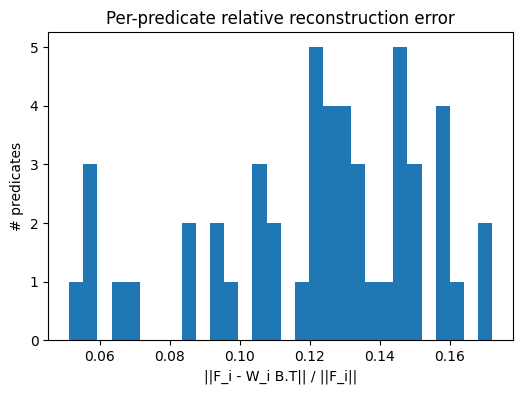

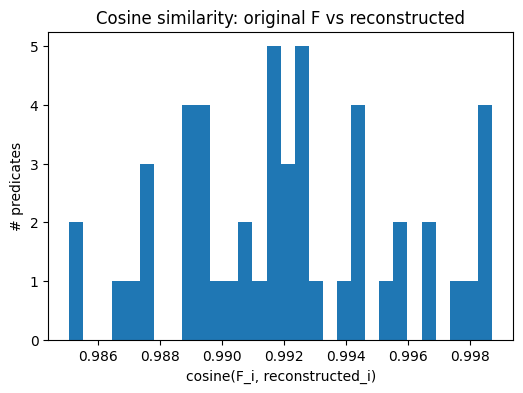

In [101]:
print("Diagnostic A1: Reconstruction quality")

residual = features.cpu() - reconstructed
per_predicate_error = residual.norm(dim=1)
feature_norm = features.cpu().norm(dim=1).clamp_min(1e-12)
relative_error = per_predicate_error / feature_norm
cosine_to_reconstruction = F.cosine_similarity(features.cpu(), reconstructed, dim=1)

print("What this means:")
print("- Low relative error means W @ B.T keeps most of the original CLIP description feature.")
print("- High cosine means the reconstructed feature points in a similar semantic direction.")
print("\nGlobal reconstruction stats:")
print("Frobenius error:", float(factor_payload["reconstruction_error"]))
print("Mean per-predicate L2 error:", float(per_predicate_error.mean()))
print("Median per-predicate L2 error:", float(per_predicate_error.median()))
print("Mean relative error:", float(relative_error.mean()))
print("Median relative error:", float(relative_error.median()))
print("Mean cosine(F, reconstructed):", float(cosine_to_reconstruction.mean()))
print("Min cosine(F, reconstructed):", float(cosine_to_reconstruction.min()))

worst_k = min(10, len(predicate_names))
worst_indices = torch.argsort(relative_error, descending=True)[:worst_k].tolist()
print(f"\nWorst {worst_k} reconstructed predicates by relative error:")
for row_id in worst_indices:
    print({
        "predicate_index": predicate_indices[row_id],
        "predicate": predicate_names[row_id],
        "relative_error": round(float(relative_error[row_id]), 4),
        "cosine": round(float(cosine_to_reconstruction[row_id]), 4),
        "used_fallback": bool(fallback_mask[row_id]),
    })

plt.figure(figsize=(6, 4))
plt.hist(relative_error.numpy(), bins=30)
plt.title("Per-predicate relative reconstruction error")
plt.xlabel("||F_i - W_i B.T|| / ||F_i||")
plt.ylabel("# predicates")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cosine_to_reconstruction.numpy(), bins=30)
plt.title("Cosine similarity: original F vs reconstructed")
plt.xlabel("cosine(F_i, reconstructed_i)")
plt.ylabel("# predicates")
plt.show()


Diagnostic A2: Optimization loss curve
First record: {'step': 1, 'total_loss': 4.876811981201172, 'recon_loss': 47.75584411621094, 'sparse_loss': 0.9523271918296814, 'ortho_loss': 5.994701862335205}
Last record: {'step': 3000, 'total_loss': 0.10367260873317719, 'recon_loss': 0.7879735827445984, 'sparse_loss': 0.2442431002855301, 'ortho_loss': 0.4509381055831909}
What to look for: total_loss and recon_loss should decrease and then stabilize.


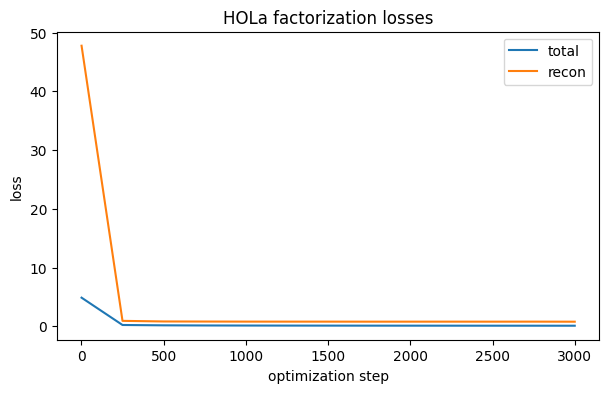

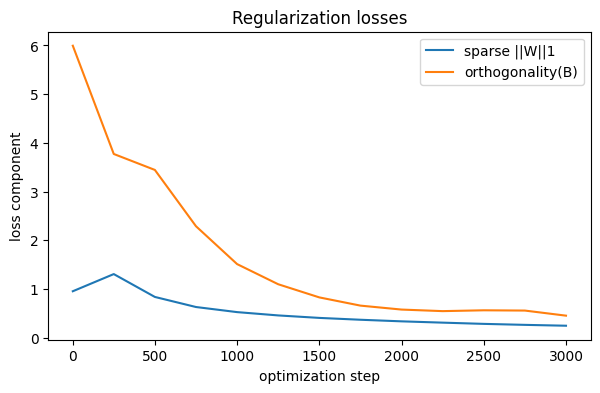

In [102]:
print("Diagnostic A2: Optimization loss curve")

history = factor_payload["loss_history"]
if not history:
    print("No loss history was recorded. Set PRINT_EVERY to a positive value.")
else:
    steps = [item["step"] for item in history]
    total_losses = [item["total_loss"] for item in history]
    recon_losses = [item["recon_loss"] for item in history]
    sparse_losses = [item["sparse_loss"] for item in history]
    ortho_losses = [item["ortho_loss"] for item in history]

    print("First record:", history[0])
    print("Last record:", history[-1])
    print("What to look for: total_loss and recon_loss should decrease and then stabilize.")

    plt.figure(figsize=(7, 4))
    plt.plot(steps, total_losses, label="total")
    plt.plot(steps, recon_losses, label="recon")
    plt.xlabel("optimization step")
    plt.ylabel("loss")
    plt.title("HOLa factorization losses")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(steps, sparse_losses, label="sparse ||W||1")
    plt.plot(steps, ortho_losses, label="orthogonality(B)")
    plt.xlabel("optimization step")
    plt.ylabel("loss component")
    plt.title("Regularization losses")
    plt.legend()
    plt.show()


Diagnostic A3: Basis disentanglement / orthogonality
What this means:
- Each row of basis_feat is one shared basis feature, matching the original HOLa code.
- After row normalization, basis_feat @ basis_feat.T should have small off-diagonal values.
- Smaller off-diagonal correlation means more disentangled shared basis features.

Basis norm stats:
min norm: 6.886085033416748
mean norm: 9.043685913085938
max norm: 11.57796573638916

Disentanglement stats:
mean abs off-diagonal: 0.009183739311993122
max abs off-diagonal: 0.28820332884788513
HOLa-style disentangle loss: 0.45089107751846313


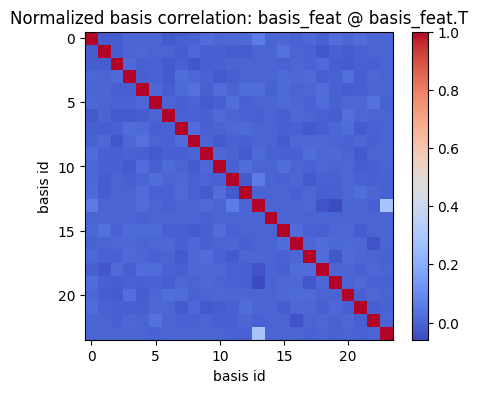

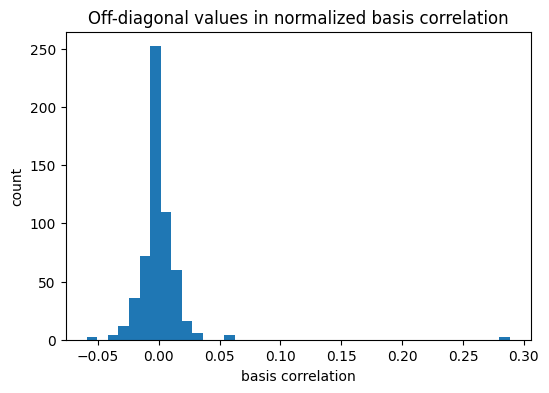

In [103]:
print("Diagnostic A3: Basis disentanglement / orthogonality")

basis_unit = basis_feat / basis_feat.norm(dim=-1, keepdim=True).clamp_min(1e-12)
basis_corr = basis_unit @ basis_unit.t()
off_diag = basis_corr - torch.diag(torch.diag(basis_corr))
row_norms = basis_feat.norm(dim=-1)

print("What this means:")
print("- Each row of basis_feat is one shared basis feature, matching the original HOLa code.")
print("- After row normalization, basis_feat @ basis_feat.T should have small off-diagonal values.")
print("- Smaller off-diagonal correlation means more disentangled shared basis features.")
print("\nBasis norm stats:")
print("min norm:", float(row_norms.min()))
print("mean norm:", float(row_norms.mean()))
print("max norm:", float(row_norms.max()))
print("\nDisentanglement stats:")
print("mean abs off-diagonal:", float(off_diag.abs().mean()))
print("max abs off-diagonal:", float(off_diag.abs().max()))
print("HOLa-style disentangle loss:", float(hola_disentangle_basis_loss(basis_feat)))

plt.figure(figsize=(5, 4))
plt.imshow(basis_corr.numpy(), cmap="coolwarm")
plt.colorbar()
plt.title("Normalized basis correlation: basis_feat @ basis_feat.T")
plt.xlabel("basis id")
plt.ylabel("basis id")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(off_diag.flatten().numpy(), bins=40)
plt.title("Off-diagonal values in normalized basis correlation")
plt.xlabel("basis correlation")
plt.ylabel("count")
plt.show()


Diagnostic A4: Weight sparsity
What this means:
- Fewer active basis dimensions per predicate means W is more sparse/compositional.
- If every predicate activates every basis, increase BETA_SPARSE or reduce RANK.
{'threshold': 0.001, 'mean_active_basis': 17.36, 'median_active_basis': 17.0, 'min_active_basis': 11, 'max_active_basis': 22}
{'threshold': 0.01, 'mean_active_basis': 4.36, 'median_active_basis': 4.0, 'min_active_basis': 1, 'max_active_basis': 11}
{'threshold': 0.05, 'mean_active_basis': 1.0, 'median_active_basis': 1.0, 'min_active_basis': 1, 'max_active_basis': 1}
{'threshold': 0.1, 'mean_active_basis': 1.0, 'median_active_basis': 1.0, 'min_active_basis': 1, 'max_active_basis': 1}

W magnitude stats:
mean L1 per predicate: 0.2438860386610031
median L1 per predicate: 0.23993507027626038
mean max |weight| per predicate: 0.1315624862909317


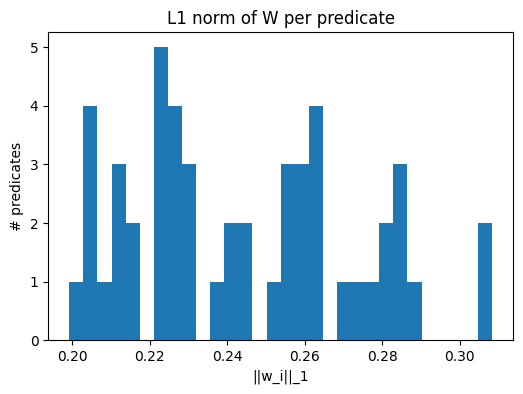

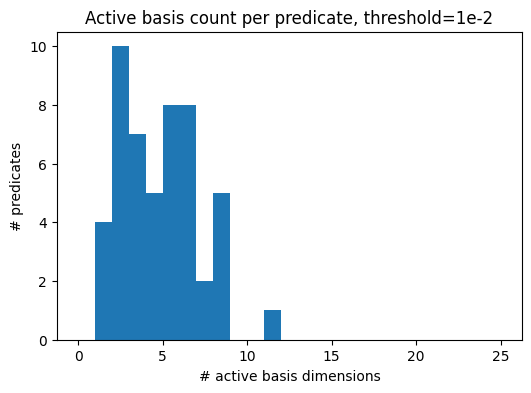

In [104]:
print("Diagnostic A4: Weight sparsity")

abs_W = W.abs()
thresholds = [1e-3, 1e-2, 5e-2, 1e-1]
print("What this means:")
print("- Fewer active basis dimensions per predicate means W is more sparse/compositional.")
print("- If every predicate activates every basis, increase BETA_SPARSE or reduce RANK.")

for threshold in thresholds:
    active_counts = (abs_W > threshold).sum(dim=1)
    print({
        "threshold": threshold,
        "mean_active_basis": round(float(active_counts.float().mean()), 3),
        "median_active_basis": round(float(active_counts.float().median()), 3),
        "min_active_basis": int(active_counts.min()),
        "max_active_basis": int(active_counts.max()),
    })

l1_per_predicate = abs_W.sum(dim=1)
max_weight_per_predicate = abs_W.max(dim=1).values
print("\nW magnitude stats:")
print("mean L1 per predicate:", float(l1_per_predicate.mean()))
print("median L1 per predicate:", float(l1_per_predicate.median()))
print("mean max |weight| per predicate:", float(max_weight_per_predicate.mean()))

plt.figure(figsize=(6, 4))
plt.hist(l1_per_predicate.numpy(), bins=30)
plt.title("L1 norm of W per predicate")
plt.xlabel("||w_i||_1")
plt.ylabel("# predicates")
plt.show()

active_counts = (abs_W > 1e-2).sum(dim=1)
plt.figure(figsize=(6, 4))
plt.hist(active_counts.numpy(), bins=range(0, rank + 2))
plt.title("Active basis count per predicate, threshold=1e-2")
plt.xlabel("# active basis dimensions")
plt.ylabel("# predicates")
plt.show()


## 7. Diagnostics B: does the decomposition reveal useful predicate semantics?

This section checks whether the learned representation is semantically meaningful, not just numerically reconstructive.

We compare three spaces:

- `F`: original CLIP description features.
- `F_hat = W @ basis_feat`: low-rank reconstructed features.
- `W`: sparse predicate weights over shared basis features.

Useful signs:

- Similar predicates become neighbors in `W` or `F_hat`.
- Each basis dimension has interpretable high-weight predicates.
- Fallback descriptions are easy to identify, because they may be less semantically rich than future LLM descriptions.


In [105]:
def cosine_similarity_matrix(x: torch.Tensor) -> torch.Tensor:
    x = F.normalize(x.float(), dim=-1)
    return x @ x.t()


def topk_neighbors(similarity: torch.Tensor, row_id: int, k: int = 5):
    values, indices = torch.topk(similarity[row_id], k=min(k + 1, similarity.shape[0]))
    neighbors = []
    for value, index in zip(values.tolist(), indices.tolist()):
        if index == row_id:
            continue
        neighbors.append((index, value))
        if len(neighbors) == k:
            break
    return neighbors


sim_name_only = cosine_similarity_matrix(name_only_features.cpu())
sim_F = cosine_similarity_matrix(features.cpu())
sim_reconstructed = cosine_similarity_matrix(reconstructed)
sim_W = cosine_similarity_matrix(W)

print("Diagnostic B1: Nearest-neighbor predicate comparison")
print("What this means:")
print("- Name-only neighbors show the raw relation token semantics without descriptions.")
print("- F neighbors show CLIP's similarity after adding descriptions/fallback prompts.")
print("- F_hat neighbors show the denoised low-rank semantic space.")
print("- W neighbors show predicates that use similar shared basis combinations.")
print("- Comparing all four tells you whether descriptions and low-rank structure sharpen the semantics.")

query_predicates = ["on", "under", "riding", "holding", "wearing", "near", "behind", "in front of"]
available = {normalize_key(name): i for i, name in enumerate(predicate_names)}
query_rows = [available[normalize_key(name)] for name in query_predicates if normalize_key(name) in available]
if not query_rows:
    query_rows = list(range(min(8, len(predicate_names))))

for row_id in query_rows:
    print("\nQuery:", {"predicate_index": predicate_indices[row_id], "predicate": predicate_names[row_id]})
    for label, sim in [
        ("Name only", sim_name_only),
        ("Description F", sim_F),
        ("Low-rank F_hat", sim_reconstructed),
        ("Weight W", sim_W),
    ]:
        neighbors = topk_neighbors(sim, row_id, k=5)
        formatted = [
            {"predicate": predicate_names[idx], "score": round(score, 4)}
            for idx, score in neighbors
        ]
        print(label, formatted)


Diagnostic B1: Nearest-neighbor predicate comparison
What this means:
- Name-only neighbors show the raw relation token semantics without descriptions.
- F neighbors show CLIP's similarity after adding descriptions/fallback prompts.
- F_hat neighbors show the denoised low-rank semantic space.
- W neighbors show predicates that use similar shared basis combinations.
- Comparing all four tells you whether descriptions and low-rank structure sharpen the semantics.

Query: {'predicate_index': 31, 'predicate': 'on'}
Name only [{'predicate': 'of', 'score': 0.9707}, {'predicate': 'in', 'score': 0.9705}, {'predicate': 'for', 'score': 0.9666}, {'predicate': 'to', 'score': 0.9606}, {'predicate': 'and', 'score': 0.9598}]
Description F [{'predicate': 'part of', 'score': 0.9503}, {'predicate': 'from', 'score': 0.9495}, {'predicate': 'has', 'score': 0.9486}, {'predicate': 'at', 'score': 0.9465}, {'predicate': 'with', 'score': 0.9451}]
Low-rank F_hat [{'predicate': 'part of', 'score': 0.9757}, {'pred

In [106]:
print("Diagnostic B2: Basis interpretation from W")
print("What this means:")
print("- For each basis dimension k, predicates with the largest positive/negative W[:, k] reveal what that basis may encode.")
print("- If the top predicates share a recognizable relation type, that basis is interpretable.")

TOPK_PER_BASIS = 8
for basis_id in range(rank):
    weights = W[:, basis_id]
    top_pos = torch.topk(weights, k=min(TOPK_PER_BASIS, len(predicate_names))).indices.tolist()
    top_neg = torch.topk(-weights, k=min(TOPK_PER_BASIS, len(predicate_names))).indices.tolist()
    print(f"\nBasis {basis_id}")
    print("  Top positive predicates:")
    for row_id in top_pos:
        print("   ", {"predicate": predicate_names[row_id], "weight": round(float(weights[row_id]), 4)})
    print("  Top negative predicates:")
    for row_id in top_neg:
        print("   ", {"predicate": predicate_names[row_id], "weight": round(float(weights[row_id]), 4)})


Diagnostic B2: Basis interpretation from W
What this means:
- For each basis dimension k, predicates with the largest positive/negative W[:, k] reveal what that basis may encode.
- If the top predicates share a recognizable relation type, that basis is interpretable.

Basis 0
  Top positive predicates:
    {'predicate': 'playing', 'weight': 0.0229}
    {'predicate': 'lying on', 'weight': 0.0188}
    {'predicate': 'flying in', 'weight': 0.0141}
    {'predicate': 'belonging to', 'weight': 0.0121}
    {'predicate': 'attached to', 'weight': 0.0111}
    {'predicate': 'on back of', 'weight': 0.0103}
    {'predicate': 'growing on', 'weight': 0.0091}
    {'predicate': 'carrying', 'weight': 0.008}
  Top negative predicates:
    {'predicate': 'wearing', 'weight': -0.0063}
    {'predicate': 'standing on', 'weight': -0.0055}
    {'predicate': 'covering', 'weight': -0.0054}
    {'predicate': 'wears', 'weight': -0.0048}
    {'predicate': 'parked on', 'weight': -0.0047}
    {'predicate': 'at', 'weigh

In [107]:
print("Diagnostic B3: Predicate-basis activation table")
print("What this means:")
print("- This shows which basis dimensions each predicate relies on most.")
print("- Sparse, meaningful top dimensions support the claim that predicates are combinations of shared basis features.")

TOPK_BASIS_PER_PREDICATE = min(5, rank)
rows_to_show = query_rows[:]
if len(rows_to_show) < min(10, len(predicate_names)):
    rows_to_show += [i for i in range(len(predicate_names)) if i not in rows_to_show][: min(10, len(predicate_names)) - len(rows_to_show)]

for row_id in rows_to_show:
    weights = W[row_id]
    top_dims = torch.topk(weights.abs(), k=TOPK_BASIS_PER_PREDICATE).indices.tolist()
    print("\nPredicate:", {"predicate_index": predicate_indices[row_id], "predicate": predicate_names[row_id]})
    print("Description:", descriptions[row_id])
    print("Used fallback:", bool(fallback_mask[row_id]))
    print("Top basis activations:")
    for basis_id in top_dims:
        print(" ", {"basis": basis_id, "weight": round(float(weights[basis_id]), 4)})


Diagnostic B3: Predicate-basis activation table
What this means:
- This shows which basis dimensions each predicate relies on most.
- Sparse, meaningful top dimensions support the claim that predicates are combinations of shared basis features.

Predicate: {'predicate_index': 31, 'predicate': 'on'}
Description: The relation "on" describes that the subject is supported by and in direct contact with the top surface of the object.
Used fallback: False
Top basis activations:
  {'basis': 13, 'weight': 0.1372}
  {'basis': 1, 'weight': 0.0149}
  {'basis': 20, 'weight': -0.009}
  {'basis': 17, 'weight': 0.0079}
  {'basis': 8, 'weight': -0.0058}

Predicate: {'predicate_index': 43, 'predicate': 'under'}
Description: The relation "under" describes that the subject is positioned vertically beneath the object with overhead coverage or support.
Used fallback: False
Top basis activations:
  {'basis': 13, 'weight': 0.1349}
  {'basis': 19, 'weight': -0.0147}
  {'basis': 2, 'weight': -0.0135}
  {'basis'

Diagnostic B4: PCA comparison across raw relations, descriptions, and low-rank reconstruction
What this means:
- Panel 1 uses only the raw relation names (no descriptions).
- Panel 2 uses the description-conditioned CLIP embeddings.
- Panel 3 uses the low-rank reconstructed embeddings in the same CLIP space.
- Panel 4 overlays all three in a shared PCA basis so each predicate's movement can be compared directly.


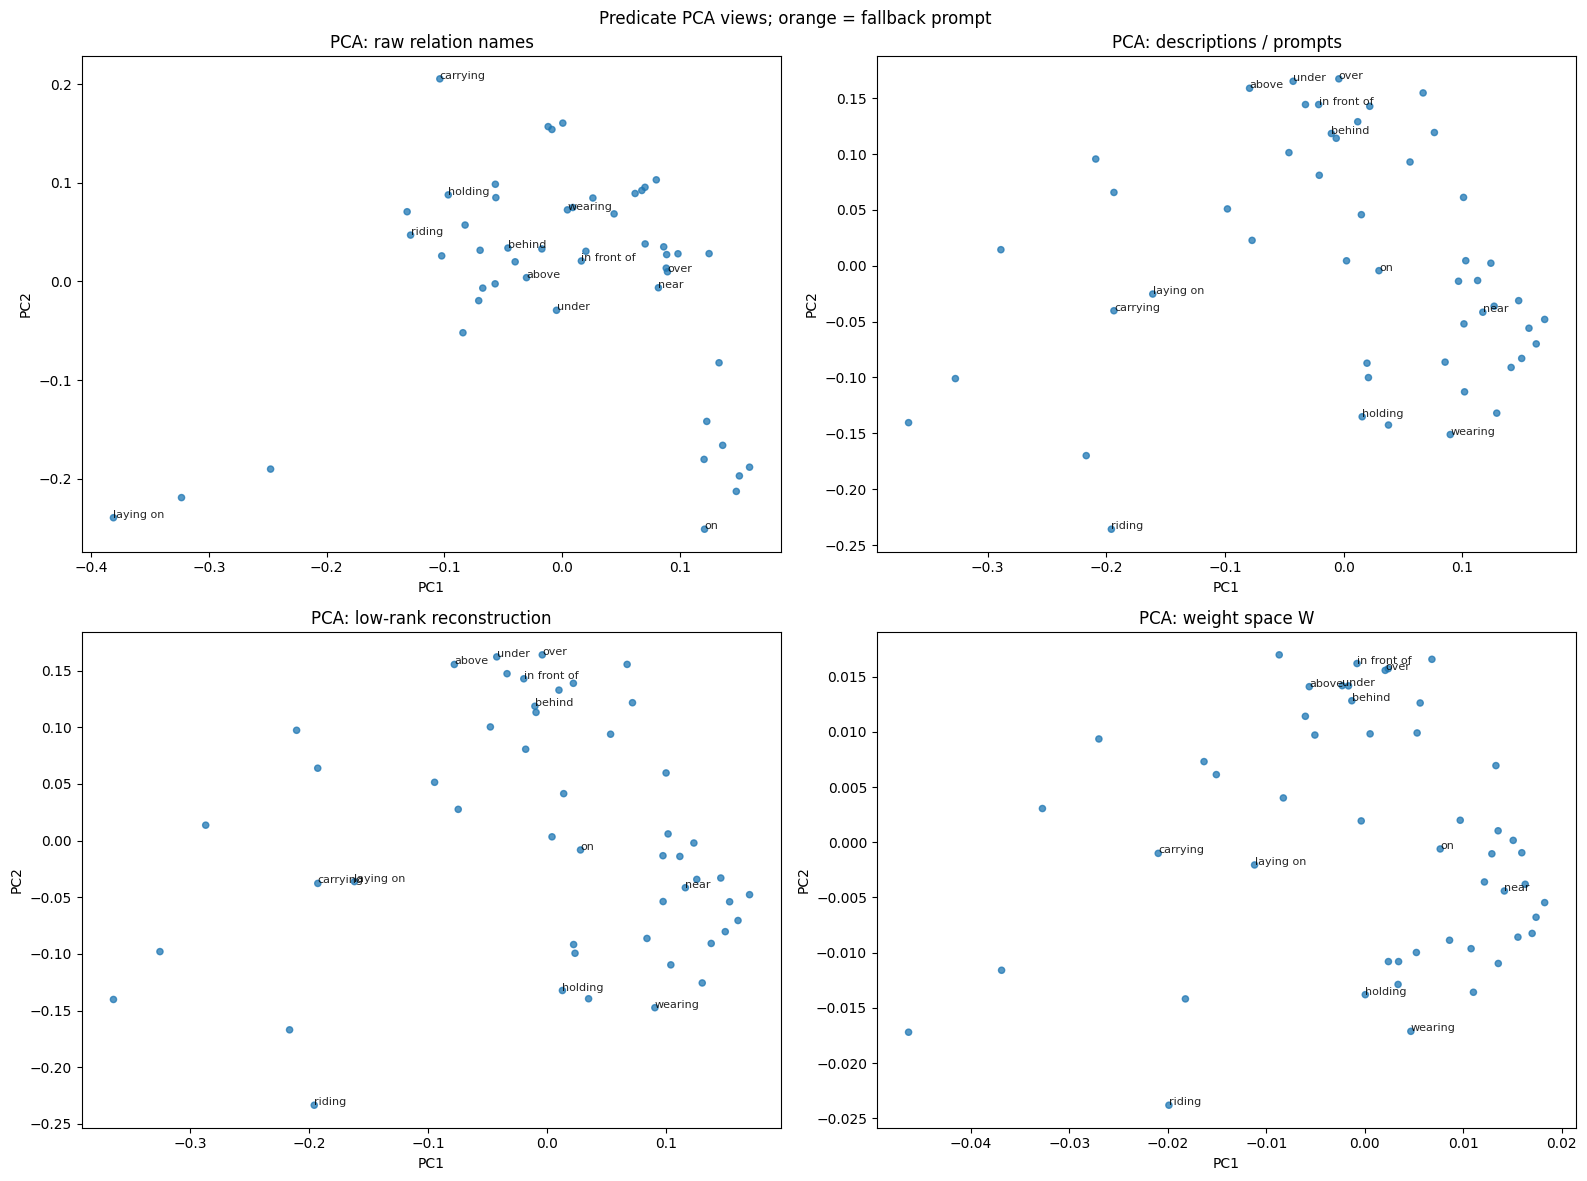

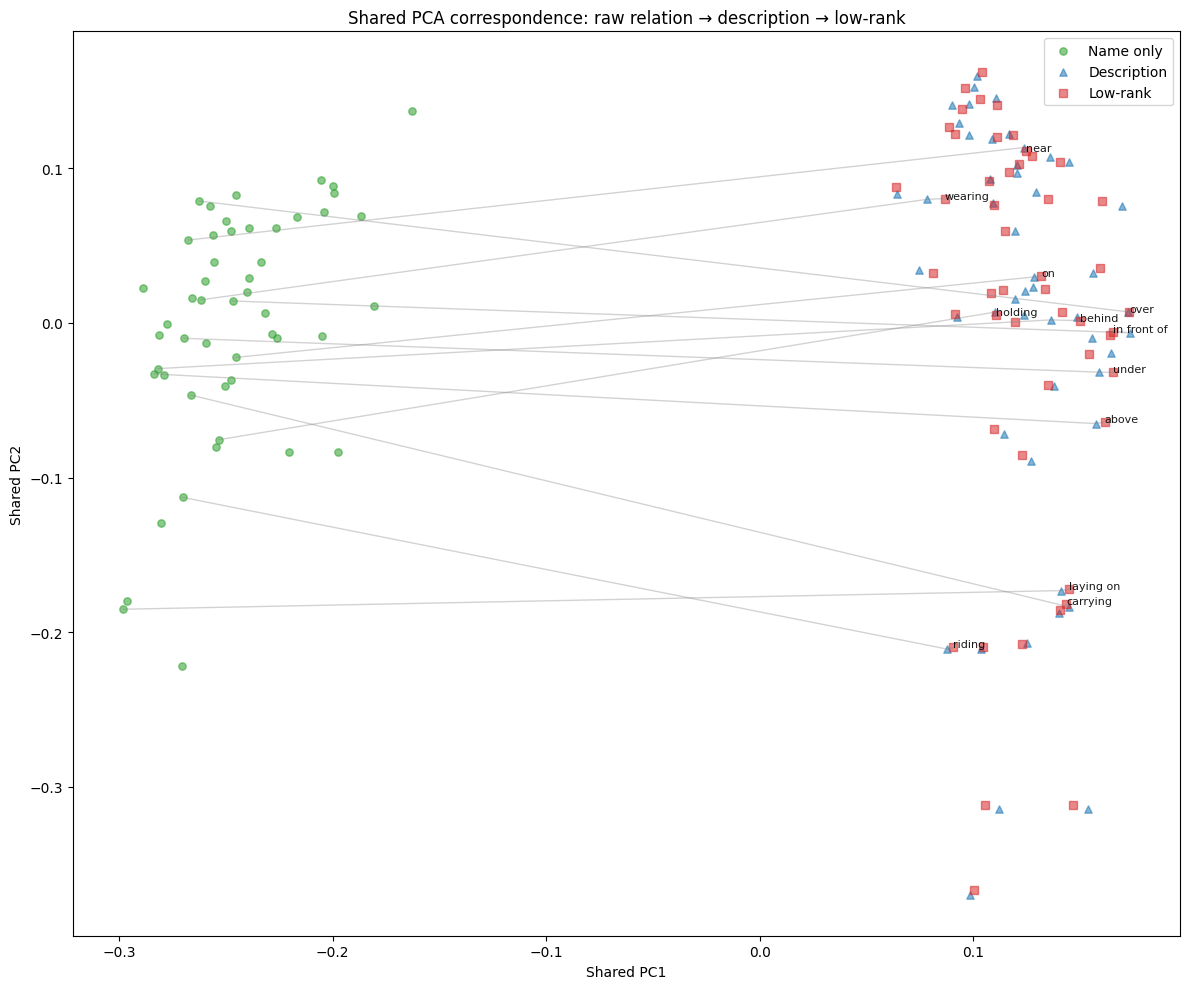

Selected predicate correspondence summary:


[{'predicate': 'on',
  'fallback': False,
  'cos(name, desc)': 0.8341,
  'cos(desc, lowrank)': 0.9898,
  'cos(name, lowrank)': 0.8348},
 {'predicate': 'under',
  'fallback': False,
  'cos(name, desc)': 0.8477,
  'cos(desc, lowrank)': 0.9919,
  'cos(name, lowrank)': 0.8374},
 {'predicate': 'riding',
  'fallback': False,
  'cos(name, desc)': 0.8671,
  'cos(desc, lowrank)': 0.9965,
  'cos(name, lowrank)': 0.864},
 {'predicate': 'holding',
  'fallback': False,
  'cos(name, desc)': 0.8792,
  'cos(desc, lowrank)': 0.9924,
  'cos(name, lowrank)': 0.8741},
 {'predicate': 'wearing',
  'fallback': False,
  'cos(name, desc)': 0.8899,
  'cos(desc, lowrank)': 0.9945,
  'cos(name, lowrank)': 0.8899},
 {'predicate': 'near',
  'fallback': False,
  'cos(name, desc)': 0.8737,
  'cos(desc, lowrank)': 0.9908,
  'cos(name, lowrank)': 0.8626},
 {'predicate': 'behind',
  'fallback': False,
  'cos(name, desc)': 0.7995,
  'cos(desc, lowrank)': 0.9917,
  'cos(name, lowrank)': 0.7941},
 {'predicate': 'in front o

In [108]:
print("Diagnostic B4: PCA comparison across raw relations, descriptions, and low-rank reconstruction")
print("What this means:")
print("- Panel 1 uses only the raw relation names (no descriptions).")
print("- Panel 2 uses the description-conditioned CLIP embeddings.")
print("- Panel 3 uses the low-rank reconstructed embeddings in the same CLIP space.")
print("- Panel 4 overlays all three in a shared PCA basis so each predicate's movement can be compared directly.")


def pca_2d(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    _, _, vh = torch.linalg.svd(x, full_matrices=False)
    return x @ vh[:2].t()


def shared_pca_projection(named_matrices):
    stacked = torch.cat([matrix.float() for _, matrix in named_matrices], dim=0)
    mean = stacked.mean(dim=0, keepdim=True)
    centered_stacked = stacked - mean
    _, _, vh = torch.linalg.svd(centered_stacked, full_matrices=False)
    basis = vh[:2].t()

    coords = {}
    for name, matrix in named_matrices:
        coords[name] = (matrix.float() - mean) @ basis
    return coords


def choose_label_rows(names, max_count=12):
    preferred = [
        "on", "under", "riding", "holding", "wearing", "near",
        "behind", "in front of", "above", "below", "inside", "over",
    ]
    lookup = {normalize_key(name): idx for idx, name in enumerate(names)}
    rows = []
    for key in preferred:
        if key in lookup and lookup[key] not in rows:
            rows.append(lookup[key])
        if len(rows) >= max_count:
            return rows
    alignment = F.cosine_similarity(features, name_only_features, dim=-1)
    fallback_priority = sorted(
        range(len(names)),
        key=lambda idx: (fallback_mask[idx], float(alignment[idx])),
    )
    for idx in fallback_priority:
        if idx not in rows:
            rows.append(idx)
        if len(rows) >= max_count:
            break
    return rows


coords_name_only = pca_2d(name_only_features.cpu())
coords_F = pca_2d(features.cpu())
coords_reconstructed = pca_2d(reconstructed)
coords_W = pca_2d(W)
shared_coords = shared_pca_projection([
    ("Name only", name_only_features.cpu()),
    ("Description", features.cpu()),
    ("Low-rank", reconstructed),
])
label_rows = choose_label_rows(predicate_names, max_count=min(12, len(predicate_names)))
colors = ["tab:orange" if used else "tab:blue" for used in fallback_mask]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, coords, title in [
    (axes[0, 0], coords_name_only, "PCA: raw relation names"),
    (axes[0, 1], coords_F, "PCA: descriptions / prompts"),
    (axes[1, 0], coords_reconstructed, "PCA: low-rank reconstruction"),
    (axes[1, 1], coords_W, "PCA: weight space W"),
]:
    ax.scatter(coords[:, 0].numpy(), coords[:, 1].numpy(), s=20, c=colors, alpha=0.75)
    for row_id in label_rows:
        ax.text(
            float(coords[row_id, 0]),
            float(coords[row_id, 1]),
            predicate_names[row_id],
            fontsize=8,
            alpha=0.85,
        )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.suptitle("Predicate PCA views; orange = fallback prompt")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
style = {
    "Name only": {"color": "tab:green", "marker": "o"},
    "Description": {"color": "tab:blue", "marker": "^"},
    "Low-rank": {"color": "tab:red", "marker": "s"},
}
for label, coords in shared_coords.items():
    ax.scatter(
        coords[:, 0].numpy(),
        coords[:, 1].numpy(),
        s=28,
        alpha=0.55,
        c=style[label]["color"],
        marker=style[label]["marker"],
        label=label,
    )

for row_id in label_rows:
    triplet = torch.stack([
        shared_coords["Name only"][row_id],
        shared_coords["Description"][row_id],
        shared_coords["Low-rank"][row_id],
    ])
    ax.plot(triplet[:, 0].numpy(), triplet[:, 1].numpy(), color="gray", alpha=0.35, linewidth=1)
    ax.text(
        float(shared_coords["Low-rank"][row_id, 0]),
        float(shared_coords["Low-rank"][row_id, 1]),
        predicate_names[row_id],
        fontsize=8,
        alpha=0.9,
    )

ax.set_title("Shared PCA correspondence: raw relation → description → low-rank")
ax.set_xlabel("Shared PC1")
ax.set_ylabel("Shared PC2")
ax.legend()
plt.tight_layout()
plt.show()

alignment_table = []
name_desc_cos = F.cosine_similarity(name_only_features, features, dim=-1)
desc_lowrank_cos = F.cosine_similarity(features, reconstructed, dim=-1)
name_lowrank_cos = F.cosine_similarity(name_only_features, reconstructed, dim=-1)
for idx in label_rows:
    alignment_table.append({
        "predicate": predicate_names[idx],
        "fallback": bool(fallback_mask[idx]),
        "cos(name, desc)": round(float(name_desc_cos[idx]), 4),
        "cos(desc, lowrank)": round(float(desc_lowrank_cos[idx]), 4),
        "cos(name, lowrank)": round(float(name_lowrank_cos[idx]), 4),
    })

print("Selected predicate correspondence summary:")
alignment_table


In [109]:
print("Diagnostic B5: Fallback prompt audit")
print("What this means:")
print("- Fallback rows use only predicate-name prompts. Once you add LLM descriptions, these should decrease.")
print("- If fallback rows dominate, semantic analysis mainly reflects predicate names, not rich descriptions.")

fallback_examples = [
    (idx, name, desc)
    for idx, name, desc, used_fallback in zip(predicate_indices, predicate_names, descriptions, fallback_mask)
    if used_fallback
]

print(f"Fallback rows: {len(fallback_examples)} / {len(predicate_names)}")
print("First fallback examples:")
fallback_examples[:20]


Diagnostic B5: Fallback prompt audit
What this means:
- Fallback rows use only predicate-name prompts. Once you add LLM descriptions, these should decrease.
- If fallback rows dominate, semantic analysis mainly reflects predicate names, not rich descriptions.
Fallback rows: 0 / 50
First fallback examples:


[]

## 8. Save `.pt` factors and `.json` metadata


In [110]:
def metadata_path(output_path: str) -> str:
    root, _ = os.path.splitext(output_path)
    return root + ".json"


os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)

output_payload = {
    "features": features,
    "name_only_features": name_only_features,
    "relation_texts": relation_texts,
    "W": W,
    "basis_feat": basis_feat,
    "B": B,
    "M": M,
    "reconstructed": reconstructed,
    "predicate_names": predicate_names,
    "predicate_indices": predicate_indices,
    "descriptions": descriptions,
    "rank": rank,
    "basis_init": BASIS_INIT,
    "reconstruction_error": float(factor_payload["reconstruction_error"]),
    "final_total_loss": float(factor_payload["final_total_loss"]),
    "final_recon_loss": float(factor_payload["final_recon_loss"]),
    "final_sparse_loss": float(factor_payload["final_sparse_loss"]),
    "final_ortho_loss": float(factor_payload["final_ortho_loss"]),
    "loss_history": factor_payload["loss_history"],
    "factorization_method": "learnable_hola_original_layout",
}

metadata = {
    "predicate_json": PREDICATE_JSON,
    "descriptions": DESCRIPTIONS,
    "clip_model": CLIP_MODEL,
    "device": DEVICE,
    "normalize": NORMALIZE_FEATURES,
    "requested_rank": RANK,
    "effective_rank": rank,
    "basis_init": BASIS_INIT,
    "recon_ratio_pca": RECON_RATIO_PCA,
    "factorization_steps": FACTORIZATION_STEPS,
    "factorization_lr": FACTORIZATION_LR,
    "beta_recon": BETA_RECON,
    "beta_sparse": BETA_SPARSE,
    "beta_ortho": BETA_ORTHO,
    "seed": SEED,
    "num_predicates": len(predicate_names),
    "feature_dim": int(features.shape[1]),
    "fallback_count": int(sum(fallback_mask)),
    "fallback_mask": fallback_mask,
    "predicate_names": predicate_names,
    "predicate_indices": predicate_indices,
    "relation_texts": relation_texts,
    "description_texts": descriptions,
    "reconstruction_error": float(factor_payload["reconstruction_error"]),
    "final_total_loss": float(factor_payload["final_total_loss"]),
    "final_recon_loss": float(factor_payload["final_recon_loss"]),
    "final_sparse_loss": float(factor_payload["final_sparse_loss"]),
    "final_ortho_loss": float(factor_payload["final_ortho_loss"]),
    "loss_history": factor_payload["loss_history"],
    "factorization_method": "learnable_hola_original_layout",
}

torch.save(output_payload, OUTPUT)
META_OUTPUT = metadata_path(OUTPUT)
with open(META_OUTPUT, "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, ensure_ascii=False, indent=2)

print("Saved factors:", OUTPUT)
print("Saved metadata:", META_OUTPUT)


PermissionError: [Errno 13] Permission denied: '/Users'